In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Customer_Lifetime_Value.xlsx to Customer_Lifetime_Value.xlsx


In [4]:
df = pd.read_excel("Customer_Lifetime_Value.xlsx")

In [6]:
#basic info
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

  Customer_ID  Age  Gender   Region Membership  Tenure_Months  Total_Orders  \
0       C0001   59  Female    South       Gold              3            76   
1       C0002   18  Female  Central     Silver             49            71   
2       C0003   19    Male  Central     Silver             46            15   
3       C0004   62  Female     East   Platinum             35            28   
4       C0005   20  Female    North     Silver              8             6   

   Avg_Order_Value  Total_Spent  Purchase_Frequency  Last_Purchase_Days  \
0           200.13     15209.88               25.33                  12   
1           159.02     11290.42                1.45                  35   
2           177.53      2662.95                0.33                  16   
3            92.63      2593.64                0.80                 108   
4           252.30      1513.80                0.75                 127   

   Discount_Usage  Website_Visits  Support_Tickets  Satisfaction_Score  \


In [8]:
#chk missing alues
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Region,0
Membership,0
Tenure_Months,0
Total_Orders,0
Avg_Order_Value,0
Total_Spent,0
Purchase_Frequency,0


In [9]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1446/3563149562.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1446/3563149562.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [10]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


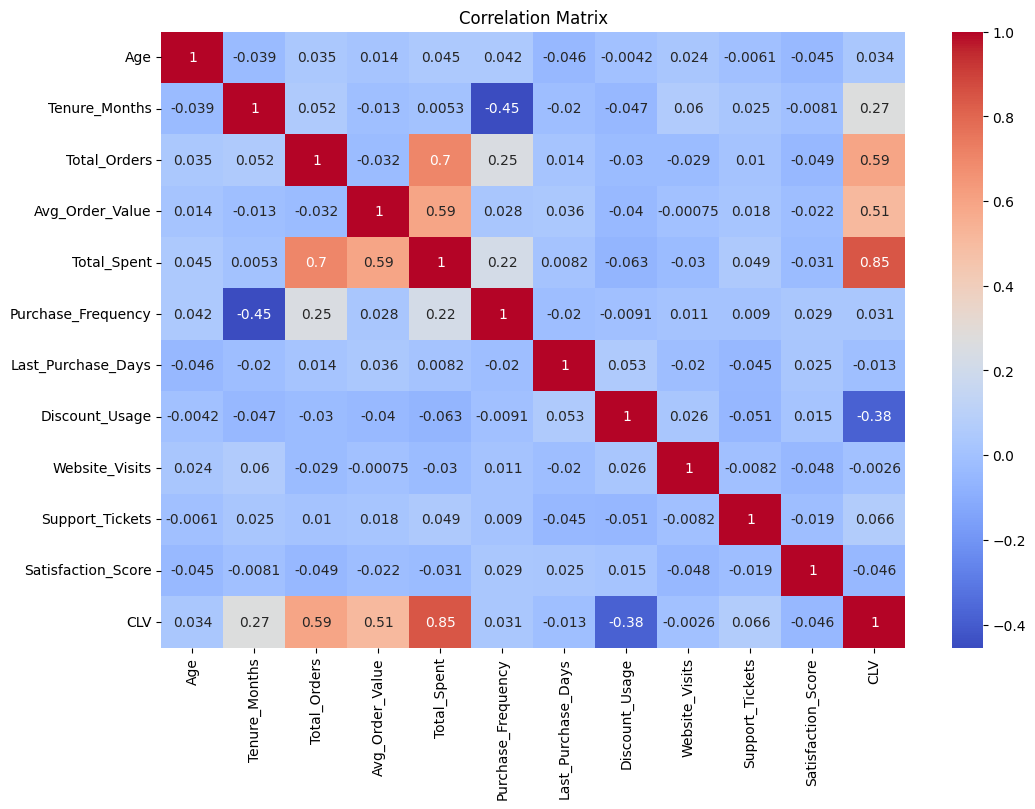

In [11]:
#correlation heatmap
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

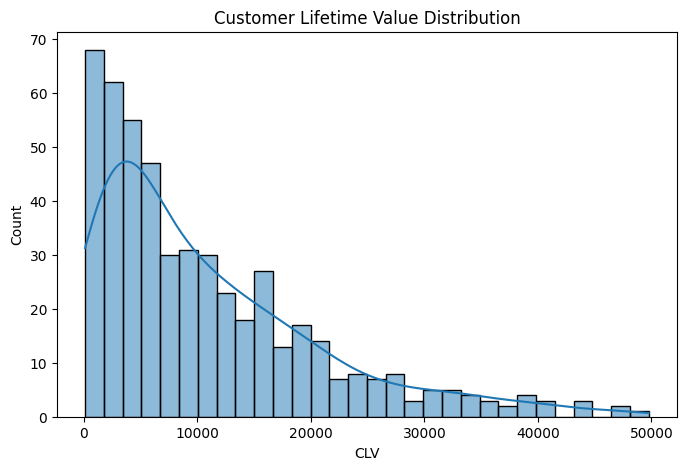

In [12]:
#CLV distribution
plt.figure(figsize=(8,5))

sns.histplot(df["CLV"], bins=30, kde=True)

plt.title("Customer Lifetime Value Distribution")
plt.show()

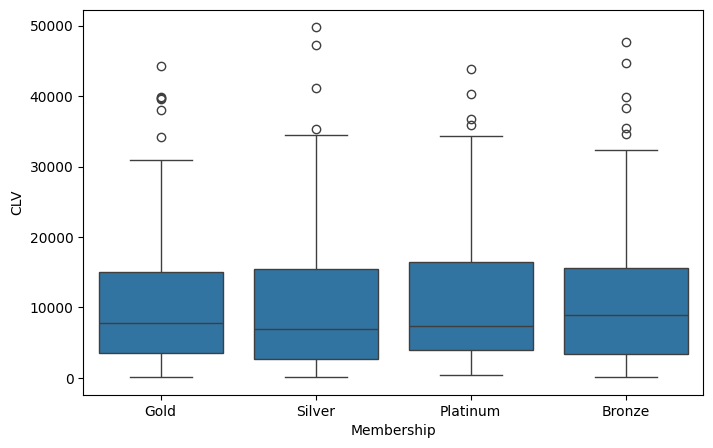

In [13]:
#membership analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Membership",
    y="CLV",
    data=df
)

plt.show()

In [14]:
#region analysis
region = df.groupby("Region")["CLV"].mean().reset_index()

fig = px.bar(
    region,
    x='Region',
    y='CLV',
    color='CLV',
    title='Average CLV by Region'
)

fig.show()

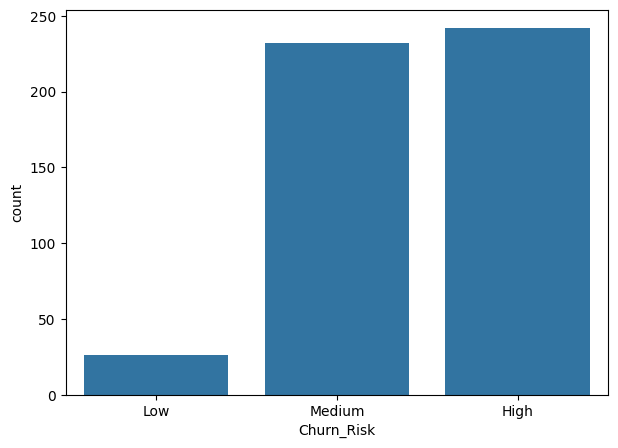

In [16]:
#churn risk analysis
plt.figure(figsize=(7,5))

sns.countplot(
    x='Churn_Risk',
    data=df
)

plt.show()

In [17]:
#feature engneering
df["Revenue_Per_Order"] = (
    df["Total_Spent"] /
    df["Total_Orders"]
)

df["Customer_Value"] = (
    df["Purchase_Frequency"] *
    df["Avg_Order_Value"]
)

df["Engagement_Score"] = (
    df["Website_Visits"] /
    (df["Last_Purchase_Days"] + 1)
)

df["Support_Ratio"] = (
    df["Support_Tickets"] /
    (df["Tenure_Months"] + 1)
)

In [18]:
#encode categorical variabale
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [19]:
#feature selection
X = df.drop("CLV", axis=1)

y = df["CLV"]

In [20]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 20)
(100, 20)


In [21]:
#sae processed data
processed = pd.concat([X, y], axis=1)

processed.to_csv(
    "processed_clv_data.csv",
    index=False
)

In [22]:
from google.colab import files

files.download(
    "processed_clv_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
!pip install xgboost lightgbm catboost shap joblib optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 17.0 MB/s eta 0:00:00


In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import shap
import joblib

In [25]:
from google.colab import files

uploaded = files.upload()

Saving processed_clv_data.csv to processed_clv_data (1).csv


In [26]:
df = pd.read_csv(
    "processed_clv_data.csv"
)

df.head()

,Customer_ID,Age,Gender,Region,Membership,Tenure_Months,Total_Orders,Avg_Order_Value,Total_Spent,Purchase_Frequency,...,Discount_Usage,Website_Visits,Support_Tickets,Satisfaction_Score,Churn_Risk,Revenue_Per_Order,Customer_Value,Engagement_Score,Support_Ratio,CLV
0,0,59,0,3,1,3,76,200.13,15209.88,25.33,...,0.07,280,0,4.6,1,200.13,5069.2929,21.538462,0.000000,14852.45
1,1,18,0,0,3,49,71,159.02,11290.42,1.45,...,0.54,202,8,3.7,2,159.02,230.5790,5.611111,0.160000,9435.03
2,2,19,1,0,3,46,15,177.53,2662.95,0.33,...,0.60,260,4,4.3,1,177.53,58.5849,15.294118,0.085106,1881.82
3,3,62,0,1,2,35,28,92.63,2593.64,0.80,...,0.60,409,3,4.2,0,92.63,74.1040,3.752294,0.083333,1642.64
4,4,20,0,2,3,8,6,252.30,1513.80,0.75,...,0.62,178,0,4.5,0,252.30,189.2250,1.390625,0.000000,651.94


In [27]:
X = df.drop(
    "CLV",
    axis=1
)

y = df["CLV"]

In [28]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 20)
(100, 20)


In [29]:
#create models
models = {

"Linear Regression":
LinearRegression(),

"Random Forest":
RandomForestRegressor(
    n_estimators=200,
    random_state=42
),


"Gradient Boosting":
GradientBoostingRegressor(
    random_state=42
),


"XGBoost":
XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
),


"LightGBM":
LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
),


"CatBoost":
CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

}

In [30]:
#train all models
results = []


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )


    prediction = model.predict(
        X_test
    )


    mae = mean_absolute_error(
        y_test,
        prediction
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )


    r2 = r2_score(
        y_test,
        prediction
    )


    results.append(
        [
            name,
            mae,
            rmse,
            r2
        ]
    )


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)


results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000813 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1585
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 20
[LightGBM] [Info] Start training from score 10593.214970
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2193.330264,3083.461158,0.923363
1,Random Forest,1302.343970,2120.150136,0.963768
2,Gradient Boosting,1124.797614,1855.997475,0.972234
3,XGBoost,1245.374358,2013.725356,0.967314
4,LightGBM,1011.891002,1672.554995,0.977451
5,CatBoost,840.486988,1543.450572,0.980798


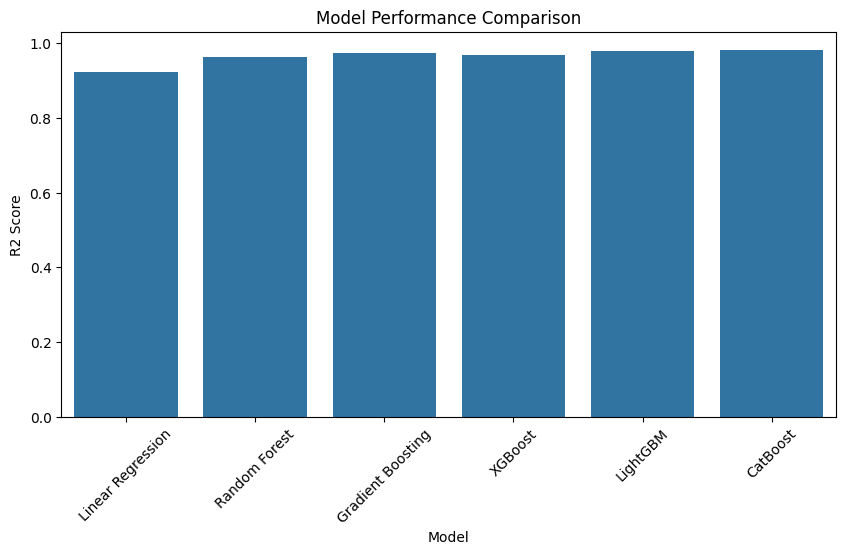

In [31]:
#model comaprision isualization
plt.figure(figsize=(10,5))


sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)


plt.xticks(rotation=45)

plt.title(
    "Model Performance Comparison"
)

plt.show()

In [32]:
#select best model
best_model_name = (
    results_df
    .sort_values(
        "R2 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)


print(
    "Best Model:",
    best_model_name
)

Best Model: CatBoost


In [39]:
xgb = XGBRegressor(
    random_state=42,
    enable_categorical=False
)


params = {

"n_estimators":
[200,300,500],

"max_depth":
[3,5,7],

"learning_rate":
[0.01,0.05,0.1]

}


grid = GridSearchCV(
    xgb,
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)


grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [200, 300, 500]},
             scoring='r2')

In [34]:
#best HGboost model
best_xgb = grid.best_estimator_


print(
    grid.best_params_
)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}


In [35]:
#evalued tuned model
pred = best_xgb.predict(
    X_test
)


print(
"MAE:",
mean_absolute_error(
    y_test,
    pred
)
)


print(
"RMSE:",
np.sqrt(
mean_squared_error(
y_test,
pred
))
)


print(
"R2:",
r2_score(
y_test,
pred
)
)

MAE: 989.0109632846834
RMSE: 1629.558369048898
R2: 0.9785958179814477


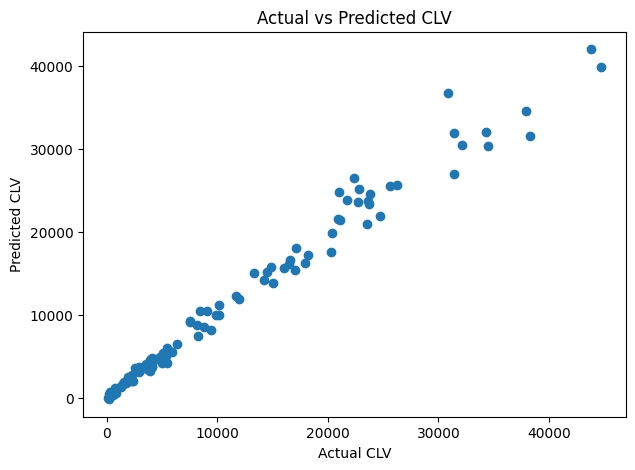

In [36]:
#actual s predictve CLV
plt.figure(figsize=(7,5))


plt.scatter(
    y_test,
    pred
)


plt.xlabel(
    "Actual CLV"
)

plt.ylabel(
    "Predicted CLV"
)


plt.title(
    "Actual vs Predicted CLV"
)


plt.show()

In [64]:
#SHAP Explainability
# Re-create and re-fit the best XGBoost model to ensure clean state for SHAP
# This addresses persistent NotImplementedError due to perceived categorical features.
optimal_xgb_model = XGBRegressor(
    random_state=42,
    enable_categorical=False,
    **grid.best_params_ # Use the best parameters found by GridSearchCV
)
optimal_xgb_model.fit(X_train, y_train)

# Ensure no categorical feature detection by SHAP for TreeExplainer
# Explicitly set these attributes to None/False for the newly created model
optimal_xgb_model.cat_feature_indices = None
if hasattr(optimal_xgb_model, '_xgb_enable_categorical'):
    optimal_xgb_model._xgb_enable_categorical = False

# Use shap.TreeExplainer directly with X_train (DataFrame) for data
explainer = shap.TreeExplainer(
    optimal_xgb_model,
    data=X_train, # Pass DataFrame for feature names
    feature_perturbation='tree_path_dependent'
)

shap_values = explainer(
    X_test # Pass DataFrame for feature names
)

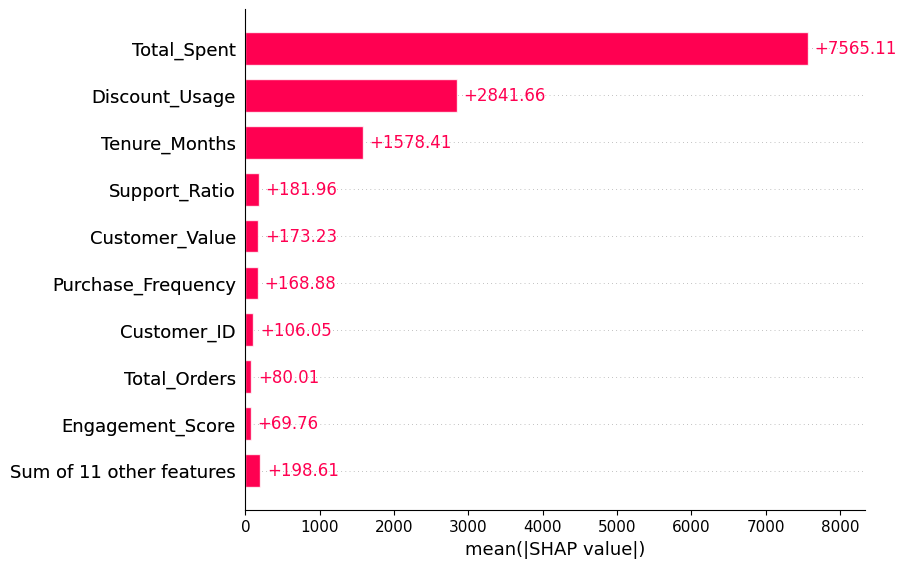

In [50]:
shap.plots.bar(
    shap_values
)

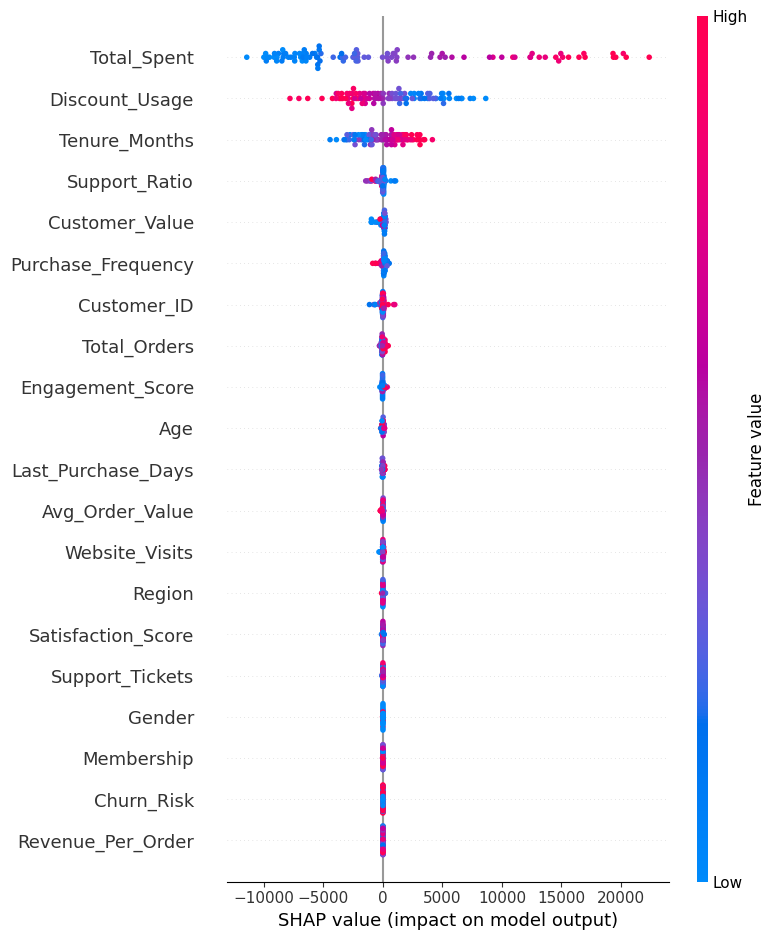

In [51]:
shap.summary_plot(
    shap_values,
    X_test
)

In [53]:
#feature importance
importance = pd.DataFrame({

"Feature":
X.columns,

"Importance":
best_xgb.feature_importances_

})


importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
8,Total_Spent,0.596979
11,Discount_Usage,0.188688
5,Tenure_Months,0.093721
19,Support_Ratio,0.076761
9,Purchase_Frequency,0.019028
0,Customer_ID,0.006740
6,Total_Orders,0.005150
18,Engagement_Score,0.002938
17,Customer_Value,0.002461
14,Satisfaction_Score,0.001771


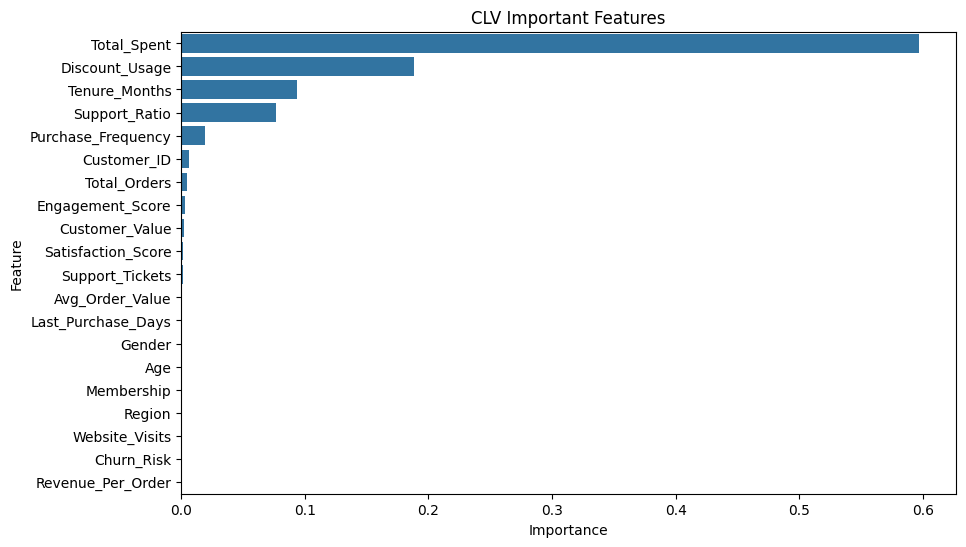

In [54]:
plt.figure(figsize=(10,6))


sns.barplot(
    data=importance.sort_values(
        "Importance",
        ascending=False
    ),
    x="Importance",
    y="Feature"
)


plt.title(
    "CLV Important Features"
)


plt.show()

In [55]:
joblib.dump(
    best_xgb,
    "clv_prediction_model.pkl"
)

['clv_prediction_model.pkl']

In [57]:
#sae feature
import json


features = list(
    X.columns
)


with open(
    "features.json",
    "w"
) as f:

    json.dump(
        features,
        f
    )

In [70]:
from google.colab import files


files.download(
    "clv_prediction_model.pkl"
)


files.download(
    "features.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
!pip install fastapi uvicorn pyngrok nest_asyncio

In [72]:
import os

os.makedirs("CLV_Project", exist_ok=True)

os.chdir("CLV_Project")

In [73]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel

import numpy as np
import pandas as pd

import joblib
import json


app = FastAPI(
    title="Customer Lifetime Value Prediction API",
    description="ML API for predicting customer lifetime value",
    version="1.0"
)



# Load Model

model = joblib.load(
    "clv_prediction_model.pkl"
)


with open(
    "features.json",
    "r"
) as f:

    features = json.load(f)



# Input Schema

class CustomerData(BaseModel):

    Age:int
    Gender:int
    Region:int
    Membership:int

    Tenure_Months:int

    Total_Orders:int

    Avg_Order_Value:float

    Total_Spent:float

    Purchase_Frequency:float

    Last_Purchase_Days:int

    Discount_Usage:float

    Website_Visits:int

    Support_Tickets:int

    Satisfaction_Score:float

    Churn_Risk:int

    Revenue_Per_Order:float

    Customer_Value:float

    Engagement_Score:float

    Support_Ratio:float



@app.get("/")
def home():

    return {

        "message":
        "CLV Prediction API Running"

    }



@app.post("/predict")
def predict(data:CustomerData):


    input_data = pd.DataFrame(
        [data.dict()]
    )


    input_data = input_data[features]


    prediction = model.predict(
        input_data
    )


    return {

        "Predicted_CLV":
        round(
            float(prediction[0]),
            2
        )

    }

Writing app.py


In [74]:
import nest_asyncio

nest_asyncio.apply()

In [75]:
import uvicorn

from threading import Thread



def run():

    uvicorn.run(
        "app:app",
        host="0.0.0.0",
        port=8000
    )


thread = Thread(
    target=run
)

thread.start()

In [76]:
from pyngrok import ngrok

In [82]:
ngrok.set_auth_token(
"3HOleQV6RIcsLpjKlOP6XhcMN72_59s5JHbi1VzBfxVnmSAiR"
)

In [83]:
from pyngrok import ngrok
from pyngrok.exception import PyngrokNgrokError

try:
    public_url = ngrok.connect(8000)
    print(f"Ngrok tunnel established at: {public_url}")
except PyngrokNgrokError as e:
    print(f"Error: Could not establish ngrok tunnel. {e}")
    print("Please ensure you have replaced 'YOUR_NGROK_TOKEN' with your actual ngrok authentication token in cell '2OEwSIxhXVID'.")
    print("You can obtain your authtoken from the ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken")
    public_url = None

if public_url:
    print(public_url)
else:
    print("Failed to get a public URL.")

Ngrok tunnel established at: NgrokTunnel: "https://robin-encrust-doodle.ngrok-free.dev" -> "http://localhost:8000"
NgrokTunnel: "https://robin-encrust-doodle.ngrok-free.dev" -> "http://localhost:8000"


In [84]:
os.makedirs(
"frontend",
exist_ok=True
)

In [85]:
%%writefile frontend/index.html


<!DOCTYPE html>

<html>

<head>

<title>
CLV Predictor
</title>


<style>

body{

font-family:Arial;

background:#f4f7fb;

}


.container{

width:500px;

margin:50px auto;

background:white;

padding:30px;

border-radius:15px;

box-shadow:0px 0px 20px gray;

}



input{

width:100%;

padding:10px;

margin:8px;

}


button{

width:100%;

padding:12px;

background:#2563eb;

color:white;

border:none;

border-radius:8px;

font-size:18px;

}


.result{

margin-top:20px;

font-size:25px;

color:green;

}


</style>


</head>



<body>


<div class="container">


<h1>
Customer Lifetime Value Prediction
</h1>



<input id="Age" placeholder="Age">


<input id="Tenure_Months" placeholder="Tenure Months">


<input id="Total_Orders" placeholder="Total Orders">


<input id="Avg_Order_Value" placeholder="Average Order Value">


<input id="Total_Spent" placeholder="Total Spent">


<input id="Purchase_Frequency" placeholder="Purchase Frequency">


<input id="Website_Visits" placeholder="Website Visits">


<input id="Satisfaction_Score" placeholder="Satisfaction Score">



<button onclick="predict()">

Predict CLV

</button>



<div class="result" id="result">

</div>


</div>




<script>


async function predict(){


let data={


Age:Number(Age.value),

Gender:1,

Region:1,

Membership:2,

Tenure_Months:Number(Tenure_Months.value),

Total_Orders:Number(Total_Orders.value),

Avg_Order_Value:Number(Avg_Order_Value.value),

Total_Spent:Number(Total_Spent.value),

Purchase_Frequency:Number(Purchase_Frequency.value),

Last_Purchase_Days:20,

Discount_Usage:0.2,

Website_Visits:Number(Website_Visits.value),

Support_Tickets:1,

Satisfaction_Score:Number(Satisfaction_Score.value),

Churn_Risk:0,

Revenue_Per_Order:100,

Customer_Value:200,

Engagement_Score:5,

Support_Ratio:0.1


}



let response =
await fetch(
"YOUR_API_URL/predict",
{

method:"POST",

headers:{

"Content-Type":"application/json"

},

body:
JSON.stringify(data)

}

)


let result =
await response.json();



document.getElementById(
"result"
)
.innerHTML=

"Predicted CLV: $"
+
result.Predicted_CLV;


}


</script>



</body>

</html>

Writing frontend/index.html


In [86]:
!pip install flask

In [87]:
from flask import Flask,send_from_directory


app = Flask(__name__)



@app.route("/")
def index():

    return send_from_directory(
        "frontend",
        "index.html"
    )



In [88]:
from threading import Thread


def run_front():

    app.run(
        host="0.0.0.0",
        port=5000
    )


Thread(
    target=run_front
).start()

In [89]:
frontend_url = ngrok.connect(5000)

frontend_url

<NgrokTunnel: "https://robin-encrust-doodle.ngrok-free.dev" -> "http://localhost:5000">